In [6]:
import os
import importlib.util

_origin = importlib.util.find_spec("data.dataset").origin
PROJECT_ROOT = os.path.dirname(os.path.dirname(_origin))
os.chdir(PROJECT_ROOT)
print(PROJECT_ROOT)

/Users/morteza/w/univercity/MLInVision/HW4/q2_homework_code


In [7]:
import torch
import torch.nn as nn
import torchvision
import torch.optim as optim
from torchvision.models import vit_b_16, ViT_B_16_Weights
import matplotlib.pyplot as plt
import numpy as np

from data.dataset import train_dataset, val_dataset, test_dataset
from data.data_loader import get_dataloader
from models.model import ViT
from scripts.train import train
from scripts.main import load_config

In [8]:
MEAN = np.array([0.4914, 0.4822, 0.4465])
STD = np.array([0.2023, 0.1994, 0.2010])


def to_display_image(img):
    arr = img.cpu().numpy().transpose(1, 2, 0)
    return np.clip(arr * STD + MEAN, 0, 1)


def draw_patch_grid(ax, image_size, patch_size):
    for p in range(patch_size, image_size, patch_size):
        ax.axhline(p - 0.5, color='white', linewidth=0.6)
        ax.axvline(p - 0.5, color='white', linewidth=0.6)


def cls_attention_grid(attn, head=None):
    # attn: (B, heads, N+1, N+1)
    if head is None:
        row = attn[0, :, 0, 1:].mean(dim=0)
    else:
        row = attn[0, head, 0, 1:]
    row = row.cpu().numpy()
    size = int(np.sqrt(row.shape[-1]))
    return row.reshape(size, size)

In [9]:
cfg = load_config("./config/config.yaml")
mcfg = cfg['model']
tcfg = cfg['training']
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

model = ViT(
    image_size=mcfg['image_size'],
    patch_size=mcfg['patch_size'],
    embedding_dim=mcfg['embedding_dim'],
    num_heads=mcfg['num_heads'],
    num_layers=mcfg['num_layers'],
    num_classes=mcfg['num_classes'],
    mlp_hidden_dim=mcfg.get('mlp_hidden_dim'),
).to(device)

Using device: mps


In [10]:

train_loader = get_dataloader(train_dataset, batch_size=tcfg['batch_size'])
val_loader = get_dataloader(val_dataset, batch_size=tcfg['batch_size'], shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=tcfg['lr'], weight_decay=tcfg['weight_decay'])

train(model, train_loader, val_loader, optimizer, criterion, device, epochs=tcfg['epochs'])
model.eval()
print()


--- Starting Training loop (5 epochs) ---
Epoch 1 Train Loss: 1.7175 Train Acc: 36.24% Val Loss: 1.7175 Val Acc: 36.24% Duration: 19.9s
Epoch 2 Train Loss: 1.3105 Train Acc: 52.37% Val Loss: 1.3105 Val Acc: 52.37% Duration: 16.1s
Epoch 3 Train Loss: 1.1445 Train Acc: 58.54% Val Loss: 1.1445 Val Acc: 58.54% Duration: 16.6s
Epoch 4 Train Loss: 1.0505 Train Acc: 61.96% Val Loss: 1.0505 Val Acc: 61.96% Duration: 16.1s
Epoch 5 Train Loss: 0.9729 Train Acc: 65.15% Val Loss: 0.9729 Val Acc: 65.15% Duration: 16.2s



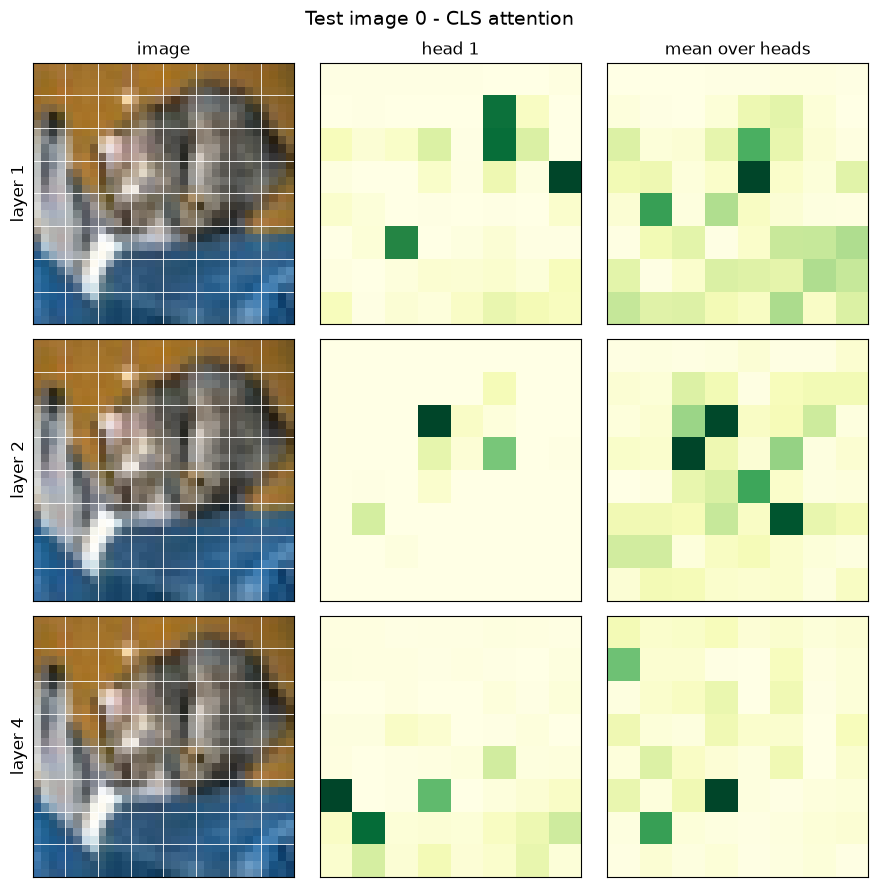

Saved ../report/images/attn_img1.png


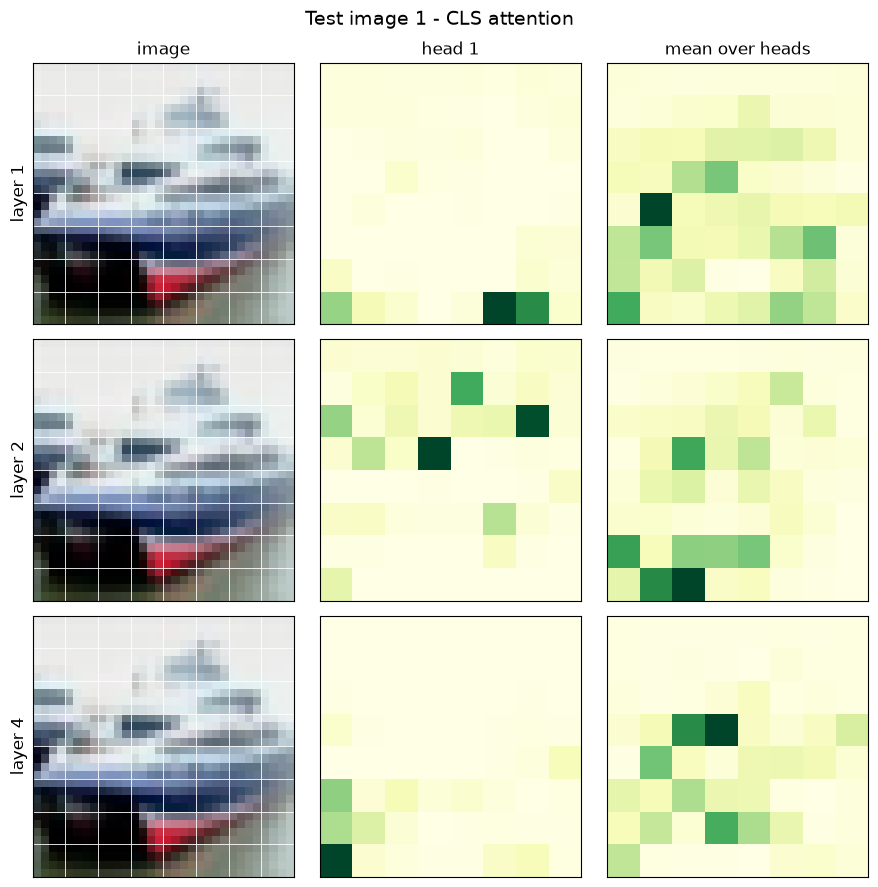

Saved ../report/images/attn_img2.png


In [11]:
indices = [0, 1]
layer_idxs = [0, 1, 3]  
col_titles = ["image", "head 1", "mean over heads"]
IMAGES_DIR = os.path.join("..", "report", "images")
os.makedirs(IMAGES_DIR, exist_ok=True)

for i, idx in enumerate(indices):
    img, label = test_dataset[idx]
    x = img.unsqueeze(0).to(device)
    with torch.no_grad():
        model(x)

    disp = to_display_image(img)
    
    fig, axes = plt.subplots(len(layer_idxs), 3, figsize=(9, 3 * len(layer_idxs)))



    for r, li in enumerate(layer_idxs):
        attn = getattr(model.layers[li].mha, 'last_attn', None)

        axes[r, 0].imshow(disp)
        draw_patch_grid(axes[r, 0], mcfg['image_size'], mcfg['patch_size'])
        axes[r, 0].set_ylabel(f"layer {li + 1}", fontsize=12)

        axes[r, 1].imshow(cls_attention_grid(attn, head=0), cmap='YlGn')
        axes[r, 2].imshow(cls_attention_grid(attn, head=None), cmap='YlGn')

        for c in range(3):
            axes[r, c].set_xticks([])
            axes[r, c].set_yticks([])

    for c, t in enumerate(col_titles):
        axes[0, c].set_title(t)

    fig.suptitle(f"Test image {idx} - CLS attention", fontsize=14)
    fig.tight_layout()
    outp = os.path.join(IMAGES_DIR, f"attn_img{i + 1}.png")
    fig.savefig(outp, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f"Saved {outp}")

In [12]:

weights = ViT_B_16_Weights.IMAGENET1K_V1
vit_b = vit_b_16(weights=weights).to(device)
vit_b.eval()
vit_preprocess = weights.transforms()


def make_attn_hook(block):
    def hook(module, inputs, output):
        x = module.ln_1(inputs[0])
        _, attn_w = module.self_attention(
            x, x, x, need_weights=True, average_attn_weights=False
        )
        module.last_attn = attn_w.detach()
    return hook

for block in vit_b.encoder.layers:
    block.register_forward_hook(make_attn_hook(block))

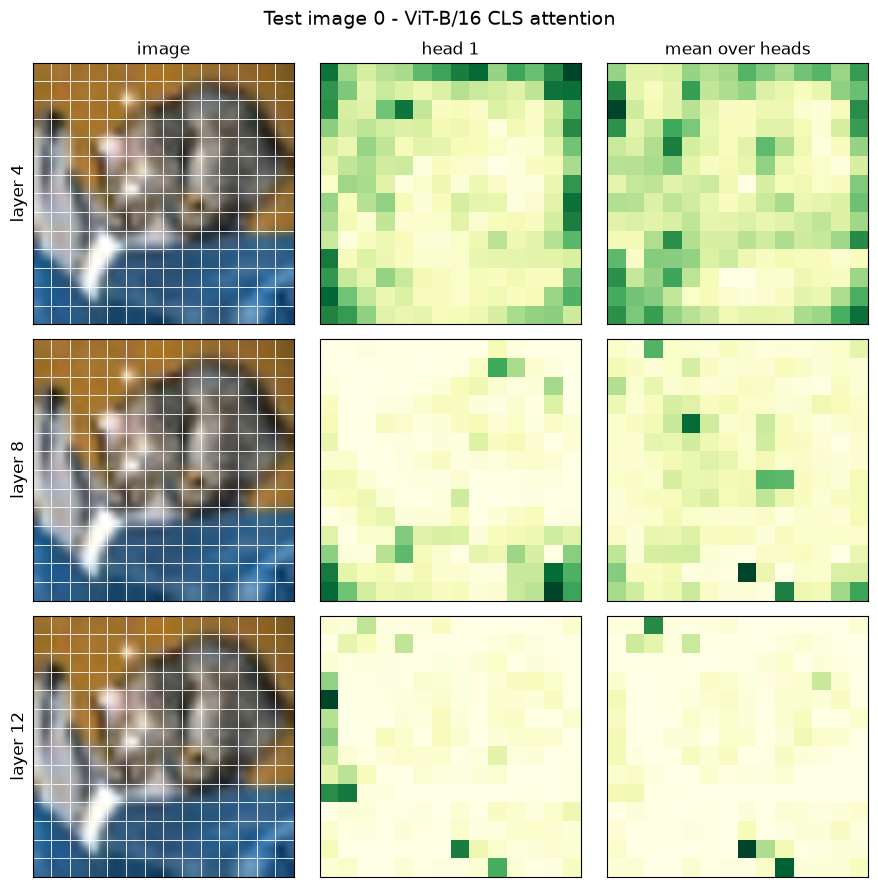

Saved ../report/images/attn_vitb16_img1.png


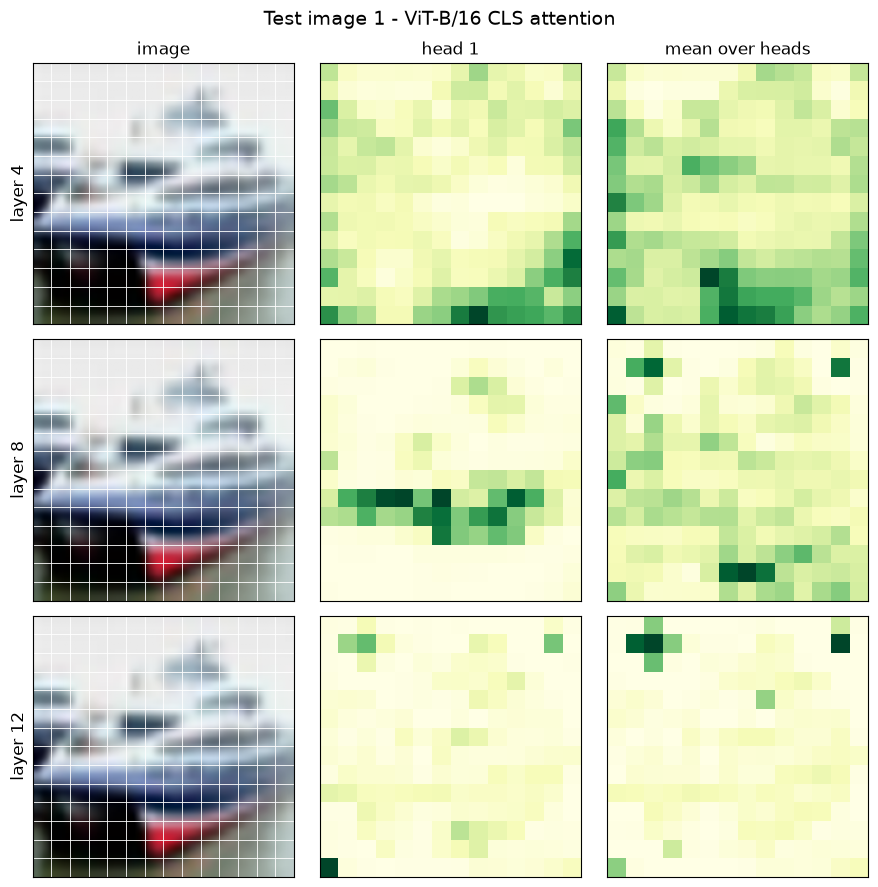

Saved ../report/images/attn_vitb16_img2.png


In [13]:
raw_test = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)

layer_idxs_b = [3, 7, 11]  

for i, idx in enumerate(indices):
    pil_img, label = raw_test[idx]
    x = vit_preprocess(pil_img).unsqueeze(0).to(device)
    with torch.no_grad():
        vit_b(x)

    disp = np.asarray(pil_img.resize((224, 224))) / 255.0

    fig, axes = plt.subplots(len(layer_idxs_b), 3, figsize=(9, 3 * len(layer_idxs_b)))

    for r, li in enumerate(layer_idxs_b):
        attn = getattr(vit_b.encoder.layers[li], 'last_attn', None)

        axes[r, 0].imshow(disp)
        draw_patch_grid(axes[r, 0], 224, 16)
        axes[r, 0].set_ylabel(f"layer {li + 1}", fontsize=12)

        axes[r, 1].imshow(cls_attention_grid(attn, head=0), cmap='YlGn')
        axes[r, 2].imshow(cls_attention_grid(attn, head=None), cmap='YlGn')

        for c in range(3):
            axes[r, c].set_xticks([])
            axes[r, c].set_yticks([])

    for c, t in enumerate(col_titles):
        axes[0, c].set_title(t)

    fig.suptitle(f"Test image {idx} - ViT-B/16 CLS attention", fontsize=14)
    fig.tight_layout()
    outp = os.path.join(IMAGES_DIR, f"attn_vitb16_img{i + 1}.png")
    fig.savefig(outp, bbox_inches='tight')
    plt.show()
    
    plt.close(fig)
    print(f"Saved {outp}")